# Document Summarization & QA using a Local LLM

The idea is to create software capable of using an LLM-based model to summarize a document and interact with it in the form of a Question-Answer format to retrieve more or specific information from the document itself.

The chain pipeline from langchain is depicted by the following structure:

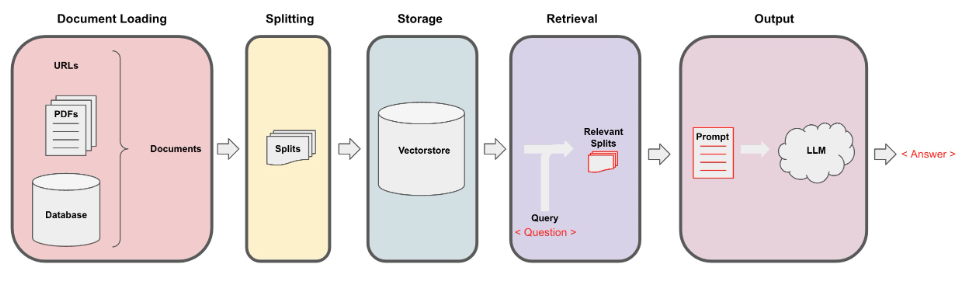

For **summarization**, we use a summarization chain to replace the retrieval (QA) stage in the first to last step.

In [1]:
# modules
import os
import time
import openai

from docgpt import loaders
from docgpt import splitters
from docgpt import storage

from dotenv import load_dotenv

from langchain.llms import GPT4All

from langchain.prompts import PromptTemplate
from langchain.chains.summarize import load_summarize_chain
from langchain.chains import RetrievalQA

## Setup

Retrieve general settings from local environment

In [2]:
# load environment
load_dotenv()

documents_dir = os.environ.get("DOCUMENTS_DIR")
vectorstore_db_dir = os.environ.get("VECTORSTORE_DB_DIR")

local_model_type = os.environ.get("LOCAL_MODEL_TYPE")
local_model_path = os.environ.get("LOCAL_MODEL_PATH")
local_embeddings_model_name = os.environ.get("EMBEDDINGS_MODEL_NAME")

# set maximum token limit for the LLM model
# set number of tokens in the prompt that are passed into the model at a time
# set amount of sources (chunks) that will be used to answer a question
max_tokens = int(os.environ.get('MODEL_MAX_TOKENS', 1_000))
batch_size = int(os.environ.get('MODEL_N_BATCH', 20))
target_sources = int(os.environ.get('TARGET_SOURCES', 5))

Load documents

In [3]:
docs = loaders.load_documents(documents_dir, verbose=True)

Loading 1 file(s) from directory 'test-documents': 100%|██████████████| 1/1 [00:00<00:00,  4.63it/s]

Loaded file from 'test-documents\bitcoin.pdf'


Split documents

In [4]:
splits = splitters.split_documents(docs, chunk_size=500, chunk_overlap=50, verbose=True)

Found 9 documents...
Split into 51 splits of texts
Each split has 500 tokens max.
Max. Total Tokens: 25,500


Create a database

In [5]:
# remove existing vectorstore
if storage.vectorstore_exists(vectorstore_db_dir):
    storage.remove_vectorstore(vectorstore_db_dir, verbose=True)
    
# create new vectorstore
db = storage.create_vectorstore(splits, vectorstore_db_dir, embeddings_model_name=local_embeddings_model_name, verbose=True)
db.persist()

Removing vectorstore at dir 'vectorstore_db'
Creating vectorstore with chromadb at dir 'vectorstore_db'
Creating embeddings using 'all-MiniLM-L6-v2' ...
Done!


## Configure LLM

Use a local model...

In [7]:
llm = GPT4All(model=local_model_path, max_tokens=max_tokens, backend='gptj', n_batch=batch_size, verbose=False)

Found model file at  models/ggml-gpt4all-j-v1.3-groovy.bin


## Summarization

Using custom prompt for instructions

## Retrieval QA

In [8]:
# set up a db retriever to look for K amount of sources from embeddings used to answer a query
retriever = db.as_retriever(search_kwargs={"k": target_sources})

# create a retrieval QA chain
qa = RetrievalQA.from_chain_type(llm=llm, chain_type="stuff", retriever=retriever, return_source_documents=False)

Run QA

In [9]:
def run_qa():
    """ Interact with documents loaded in the chroma database. """
    
    i = 1

    print("Please enter your questions inside the box and hit enter...")
    
    while True:
        query = input(f"{i}. Question: ")
    
        if query.lower() == "exit":
            break
            
        if query.strip() == "":
            print("\nPlease enter a valid query...\n\n")
            continue
    
        start = time.time()
    
        # get answer using RetrievalQA chain
        output = qa(query)
        answer = output.get("result")
    
        end = time.time()
    
        # display answer
        print(f"\nAnswer:\n{answer}")
        print(f"\nETA: {round(end - start, 2)} (s)\n")

        # increase question counter
        i += 1

In [10]:
run_qa()

Please enter your questions inside the box and hit enter...


Question #1 >  What is bitcoin?



Answer:  Bitcoin is a peer-to-peer electronic cash system without relying on trust, which allows for direct online payments between parties without going through financial institutions. It uses digital signatures to provide part of the solution and has an incentive mechanism in place that encourages nodes supporting the network. The main benefit of bitcoin lies in its ability to split and combine value within transactions containing multiple inputs from smaller amounts combined into larger ones, making it possible for payees to verify ownership without relying on a central authority or double-spending prevention mechanisms like digital signatures alone.

ETA: 270.63 (s)



Question #2 >  exit
